# YUVAA Internship — Week 5
## Strategic Recommendation and Operational Planning

**Prepared by:** Avirup Karmakar

This notebook synthesizes Weeks 1–4 into strategic recommendations, KPIs, an implementation plan and production-planning scenarios.


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Prepare the Dataset

In [4]:
df = pd.read_csv("crop_production.csv")
df.columns = [str(c).strip() for c in df.columns]

for c in ["State_Name", "District_Name", "Season", "Crop"]:
    df[c] = df[c].astype("string").str.strip()

for c in ["Crop_Year", "Area", "Production"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.drop_duplicates()

analysis_df = df.dropna(
    subset=["Crop_Year", "Area", "Production", "State_Name", "District_Name", "Season", "Crop"]
).copy()

analysis_df = analysis_df[
    (analysis_df["Area"] >= 0) &
    (analysis_df["Production"] >= 0)
].copy()

print("Rows for Week 5:", len(analysis_df))
display(analysis_df.head())


Rows for Week 5: 142214


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## 3. Build Annual and Seasonal Evidence

**Important methodological rule:** use `Whole Year` records for annual totals when available so aggregate annual records are not double-counted with seasonal records. For seasonal comparison, exclude `Whole Year`.


In [5]:
whole_year = analysis_df[
    analysis_df["Season"].str.lower().eq("whole year")
].copy()

non_whole = analysis_df[
    ~analysis_df["Season"].str.lower().eq("whole year")
].copy()

if whole_year["Crop_Year"].nunique() >= 3:
    annual = (
        whole_year.groupby("Crop_Year")["Production"]
        .sum()
        .reset_index()
        .sort_values("Crop_Year")
    )
else:
    annual = (
        non_whole.groupby("Crop_Year")["Production"]
        .sum()
        .reset_index()
        .sort_values("Crop_Year")
    )

annual["YoY_Growth_%"] = annual["Production"].pct_change()

state_totals = (
    whole_year.groupby("State_Name")["Production"].sum()
    .sort_values(ascending=False)
)

season_totals = (
    non_whole.groupby("Season")["Production"].sum()
    .sort_values(ascending=False)
)

print("Annual range:", int(annual["Crop_Year"].min()), "-", int(annual["Crop_Year"].max()))
display(annual)
print("Top states:")
display(state_totals.head(10))
print("Season totals:")
display(season_totals)


Annual range: 1997 - 2014


,Crop_Year,Production,YoY_Growth_%
0,1997,7.688188e+07,NaN
1,1998,5.341616e+09,68.478216
2,1999,5.980309e+09,0.119569
3,2000,6.990917e+09,0.168989
4,2001,6.984372e+09,-0.000936
5,2002,7.252583e+09,0.038402
6,2003,7.422195e+09,0.023386
7,2004,7.705289e+09,0.038142
8,2005,7.500391e+09,-0.026592
9,2006,7.810564e+09,0.041354


Top states:


,Production
State_Name,
Kerala,9.786933e+10
Andhra Pradesh,1.702610e+10
Assam,1.996667e+09
Andaman and Nicobar Islands,7.179722e+08
Maharashtra,6.532872e+08
Karnataka,6.249888e+08
Goa,5.041748e+08
Gujarat,2.839699e+08
Bihar,1.249036e+08


Season totals:


,Production
Season,
Kharif,1.519855e+09
Rabi,7.653442e+08
Winter,1.482661e+08
Summer,7.011204e+07
Autumn,3.803358e+07


## 4. Production Volatility and Concentration

In [6]:
mean_annual = annual["Production"].mean()
std_annual = annual["Production"].std()
cv_pct = std_annual / mean_annual * 100

top5_state_share = (
    state_totals.head(5).sum() /
    state_totals.sum() * 100
)

top_season_share = (
    season_totals.iloc[0] /
    season_totals.sum() * 100
)

print(f"Annual coefficient of variation: {cv_pct:.2f}%")
print(f"Top-5 state production share: {top5_state_share:.2f}%")
print(f"Top-season share, excluding Whole Year: {top_season_share:.2f}%")


Annual coefficient of variation: 27.41%
Top-5 state production share: 98.53%
Top-season share, excluding Whole Year: 59.80%


## 5. Baseline Forecast

In [7]:
trend_model = LinearRegression()

trend_model.fit(
    annual[["Crop_Year"]],
    annual["Production"]
)

annual["Trend_Fitted"] = trend_model.predict(
    annual[["Crop_Year"]]
)

last_year = int(annual["Crop_Year"].max())
next_year = last_year + 1

baseline = float(
    trend_model.predict([[next_year]])[0]
)

print(f"Baseline estimate for {next_year}: {baseline:,.2f}")


Baseline estimate for 2015: 8,450,435,443.33


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 6. Scenario Analysis

In [8]:
scenario_df = pd.DataFrame({
    "Scenario": [
        "Favorable Growth",
        "Baseline Trend",
        "Moderate Disruption",
        "Severe Disruption"
    ],
    "Change_vs_Baseline_%": [10, 0, -10, -20]
})

scenario_df["Projected_Production"] = (
    baseline *
    (1 + scenario_df["Change_vs_Baseline_%"] / 100)
)

display(scenario_df)


,Scenario,Change_vs_Baseline_%,Projected_Production
0,Favorable Growth,10,9.295479e+09
1,Baseline Trend,0,8.450435e+09
2,Moderate Disruption,-10,7.605392e+09
3,Severe Disruption,-20,6.760348e+09


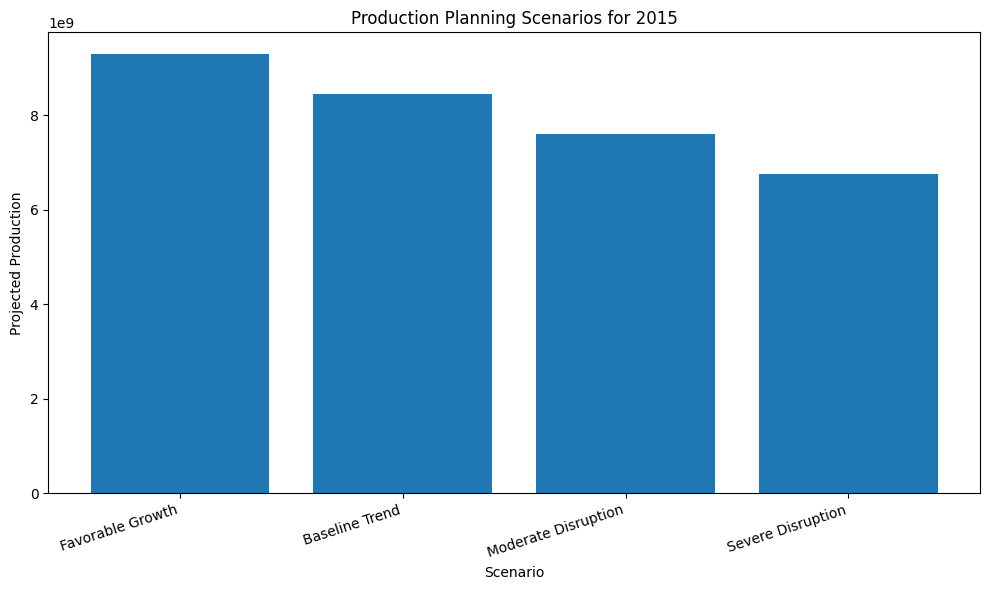

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(
    scenario_df["Scenario"],
    scenario_df["Projected_Production"]
)
plt.title(f"Production Planning Scenarios for {next_year}")
plt.xlabel("Scenario")
plt.ylabel("Projected Production")
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()


## 7. Historical Risk Signals

In [10]:
valid_growth = annual.dropna(subset=["YoY_Growth_%"])

largest_increase = valid_growth.loc[
    valid_growth["YoY_Growth_%"].idxmax()
]
largest_decline = valid_growth.loc[
    valid_growth["YoY_Growth_%"].idxmin()
]

print(
    f"Largest increase: {int(largest_increase['Crop_Year'])} "
    f"({largest_increase['YoY_Growth_%'] * 100:.2f}%)"
)

print(
    f"Largest decline: {int(largest_decline['Crop_Year'])} "
    f"({largest_decline['YoY_Growth_%'] * 100:.2f}%)"
)


Largest increase: 1998 (6847.82%)
Largest decline: 2007 (-23.03%)


## 8. KPI Framework

In [11]:
kpis = pd.DataFrame({
    "Strategy": [
        "Regional Sourcing Diversification",
        "Seasonal Procurement & Storage",
        "Forecast-Driven Procurement",
        "Production-Risk Early-Warning"
    ],
    "KPI": [
        "Top-5 regional production share",
        "Procurement readiness / storage utilization",
        "Forecast error (%)",
        "Risk response rate (%)"
    ],
    "Review_Frequency": [
        "Quarterly",
        "Seasonal / Weekly in peak periods",
        "Monthly / Quarterly",
        "Monthly"
    ]
})

display(kpis)


,Strategy,KPI,Review_Frequency
0,Regional Sourcing Diversification,Top-5 regional production share,Quarterly
1,Seasonal Procurement & Storage,Procurement readiness / storage utilization,Seasonal / Weekly in peak periods
2,Forecast-Driven Procurement,Forecast error (%),Monthly / Quarterly
3,Production-Risk Early-Warning,Risk response rate (%),Monthly


## 9. Operational Plan

In [12]:
operational_plan = pd.DataFrame({
    "Phase": ["Phase 1", "Phase 2", "Phase 3", "Phase 4"],
    "Timeline": [
        "Month 1",
        "Months 2-3",
        "Months 4-6",
        "Months 7-12"
    ],
    "Action": [
        "Baseline, priority regions and KPI definitions",
        "Alternate sourcing and seasonal capacity setup",
        "Forecast monitoring and risk alerts",
        "KPI review and threshold recalibration"
    ]
})

display(operational_plan)


,Phase,Timeline,Action
0,Phase 1,Month 1,"Baseline, priority regions and KPI definitions"
1,Phase 2,Months 2-3,Alternate sourcing and seasonal capacity setup
2,Phase 3,Months 4-6,Forecast monitoring and risk alerts
3,Phase 4,Months 7-12,KPI review and threshold recalibration


## 10. Strategic Recommendations

1. **Regional Sourcing Diversification:** develop alternate production regions and suppliers to reduce regional dependency.

2. **Seasonal Procurement and Storage Planning:** align procurement, warehousing and transport capacity with the major agricultural seasons.

3. **Forecast-Driven Procurement:** use the annual trend forecast as a baseline planning signal and monitor forecast error over time.

4. **Production-Risk Early-Warning System:** use transparent thresholds for unusual production changes and assign clear operational responses.


## 11. Conclusion

Week 5 translates agricultural data analysis into an operational strategy. The recommendations are linked to observed production concentration, seasonal patterns, historical variability, baseline forecasting and scenario sensitivity. The framework is intended for planning support and should be recalibrated when new data and business-specific operating information become available.
